In [204]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [205]:
# Create Academic Performance Dataset

data = {
    'StudentID': [1,2,3,4,5,6,7,8,9,10],

    'Gender': [
        'Male', 'Female', 'Female', 'Male',
        'Male', 'Female', np.nan,
        'Female', 'Male', 'Female'
    ],

    'Age': [
        18, 19, 20, np.nan,
        18, 19, 20, 21, 22, 100
    ],

    'MathScore': [
        85, 90, 78, 88,
        95, 40, 76, 89, 92, 300
    ],

    'EnglishScore': [
        80, 85, np.nan, 78,
        90, 45, 70, 88, 91, 250
    ],

    'ScienceScore': [
        82, 87, 75, 85,
        np.nan, 42, 74, 90, 89, 280
    ],

    'Attendance': [
        85, 90, 88, 92,
        95, 60, 70, np.nan, 89, 150
    ]
}

df = pd.DataFrame(data)

# Display dataset

df

,StudentID,Gender,Age,MathScore,EnglishScore,ScienceScore,Attendance
0,1,Male,18.0,85,80.0,82.0,85.0
1,2,Female,19.0,90,85.0,87.0,90.0
2,3,Female,20.0,78,NaN,75.0,88.0
3,4,Male,NaN,88,78.0,85.0,92.0
4,5,Male,18.0,95,90.0,NaN,95.0
5,6,Female,19.0,40,45.0,42.0,60.0
6,7,NaN,20.0,76,70.0,74.0,70.0
7,8,Female,21.0,89,88.0,90.0,NaN
8,9,Male,22.0,92,91.0,89.0,89.0
9,10,Female,100.0,300,250.0,280.0,150.0


In [206]:
# Dataset information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   StudentID     10 non-null     int64  
 1   Gender        9 non-null      object 
 2   Age           9 non-null      float64
 3   MathScore     10 non-null     int64  
 4   EnglishScore  9 non-null      float64
 5   ScienceScore  9 non-null      float64
 6   Attendance    9 non-null      float64
dtypes: float64(4), int64(2), object(1)
memory usage: 692.0+ bytes


In [207]:
# Check missing values

df.isnull().sum()

StudentID       0
Gender          1
Age             1
MathScore       0
EnglishScore    1
ScienceScore    1
Attendance      1
dtype: int64

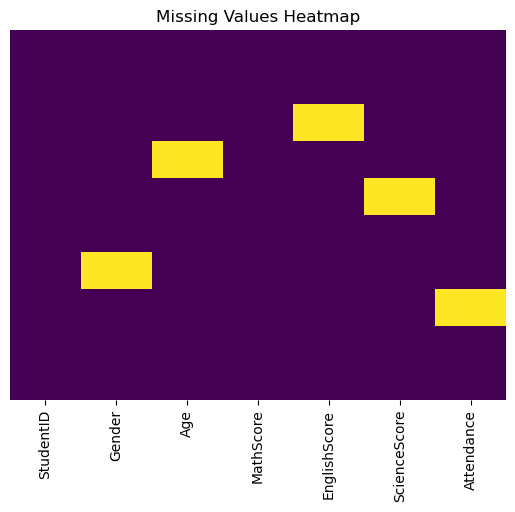

In [208]:
# Heatmap for missing values

sns.heatmap(
    df.isnull(),
    yticklabels=False,
    cbar=False,
    cmap='viridis'
)

plt.title("Missing Values Heatmap")

plt.show()

In [209]:
# Fill missing values

df['Gender'] = df['Gender'].fillna(
    df['Gender'].mode()[0]
)

df['Age'] = df['Age'].fillna(
    df['Age'].mean()
)

df['EnglishScore'] = df['EnglishScore'].fillna(
    df['EnglishScore'].mean()
)

df['ScienceScore'] = df['ScienceScore'].fillna(
    df['ScienceScore'].mean()
)

df['Attendance'] = df['Attendance'].fillna(
    df['Attendance'].mean()
)

# Display updated dataset

df

,StudentID,Gender,Age,MathScore,EnglishScore,ScienceScore,Attendance
0,1,Male,18.000000,85,80.000000,82.000000,85.0
1,2,Female,19.000000,90,85.000000,87.000000,90.0
2,3,Female,20.000000,78,97.444444,75.000000,88.0
3,4,Male,28.555556,88,78.000000,85.000000,92.0
4,5,Male,18.000000,95,90.000000,100.444444,95.0
5,6,Female,19.000000,40,45.000000,42.000000,60.0
6,7,Female,20.000000,76,70.000000,74.000000,70.0
7,8,Female,21.000000,89,88.000000,90.000000,91.0
8,9,Male,22.000000,92,91.000000,89.000000,89.0
9,10,Female,100.000000,300,250.000000,280.000000,150.0


In [210]:
# Verify missing values again

df.isnull().sum()

StudentID       0
Gender          0
Age             0
MathScore       0
EnglishScore    0
ScienceScore    0
Attendance      0
dtype: int64

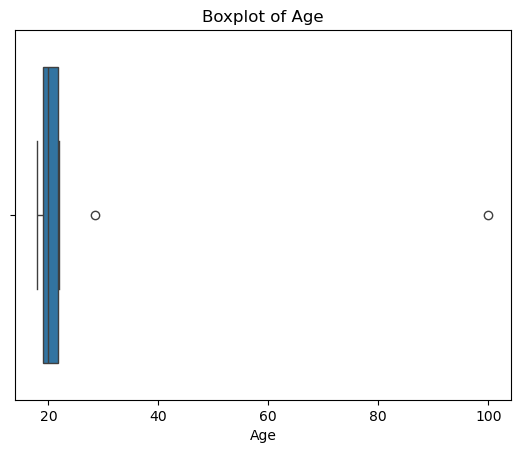

In [211]:
# Boxplot for Age

sns.boxplot(
    x=df['Age']
)

plt.title("Boxplot of Age")

plt.show()

In [212]:
# Detect and remove outliers using IQR method

Q1 = df['MathScore'].quantile(0.25)

Q3 = df['MathScore'].quantile(0.75)

IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR

upper_limit = Q3 + 1.5 * IQR

# Remove outliers

df = df[
    (df['MathScore'] >= lower_limit) &
    (df['MathScore'] <= upper_limit)
]

# Display cleaned dataset

df

,StudentID,Gender,Age,MathScore,EnglishScore,ScienceScore,Attendance
0,1,Male,18.000000,85,80.000000,82.000000,85.0
1,2,Female,19.000000,90,85.000000,87.000000,90.0
2,3,Female,20.000000,78,97.444444,75.000000,88.0
3,4,Male,28.555556,88,78.000000,85.000000,92.0
4,5,Male,18.000000,95,90.000000,100.444444,95.0
6,7,Female,20.000000,76,70.000000,74.000000,70.0
7,8,Female,21.000000,89,88.000000,90.000000,91.0
8,9,Male,22.000000,92,91.000000,89.000000,89.0


In [213]:
# Apply normalization on MathScore

df['MathScore_Normalized'] = (
    (df['MathScore'] - df['MathScore'].min()) /
    (df['MathScore'].max() - df['MathScore'].min())
)

# Display normalized values

df[['MathScore', 'MathScore_Normalized']]

C:\Users\tanis\AppData\Local\Temp\ipykernel_51056\1306346466.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['MathScore_Normalized'] = (


,MathScore,MathScore_Normalized
0,85,0.473684
1,90,0.736842
2,78,0.105263
3,88,0.631579
4,95,1.000000
6,76,0.000000
7,89,0.684211
8,92,0.842105


In [214]:
# Convert categorical variable into numeric

df['Gender'] = df['Gender'].map({
    'Male': 0,
    'Female': 1
})

# Display updated dataset

df

C:\Users\tanis\AppData\Local\Temp\ipykernel_51056\2991530335.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Gender'] = df['Gender'].map({


,StudentID,Gender,Age,MathScore,EnglishScore,ScienceScore,Attendance,MathScore_Normalized
0,1,0,18.000000,85,80.000000,82.000000,85.0,0.473684
1,2,1,19.000000,90,85.000000,87.000000,90.0,0.736842
2,3,1,20.000000,78,97.444444,75.000000,88.0,0.105263
3,4,0,28.555556,88,78.000000,85.000000,92.0,0.631579
4,5,0,18.000000,95,90.000000,100.444444,95.0,1.000000
6,7,1,20.000000,76,70.000000,74.000000,70.0,0.000000
7,8,1,21.000000,89,88.000000,90.000000,91.0,0.684211
8,9,0,22.000000,92,91.000000,89.000000,89.0,0.842105


In [215]:
# Statistical summary

df.describe()

,StudentID,Gender,Age,MathScore,EnglishScore,ScienceScore,Attendance,MathScore_Normalized
count,8.000000,8.000000,8.000000,8.000000,8.000000,8.000000,8.000000,8.000000
mean,4.875000,0.500000,20.819444,86.625000,84.930556,85.305556,87.500000,0.559211
std,2.900123,0.534522,3.418973,6.631903,8.650562,8.558905,7.653197,0.349048
min,1.000000,0.000000,18.000000,76.000000,70.000000,74.000000,70.000000,0.000000
25%,2.750000,0.000000,18.750000,83.250000,79.500000,80.250000,87.250000,0.381579
50%,4.500000,0.500000,20.000000,88.500000,86.500000,86.000000,89.500000,0.657895
75%,7.250000,1.000000,21.250000,90.500000,90.250000,89.250000,91.250000,0.763158
max,9.000000,1.000000,28.555556,95.000000,97.444444,100.444444,95.000000,1.000000


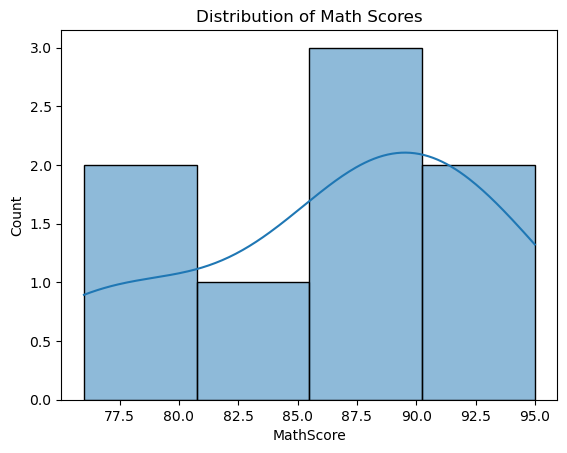

In [216]:
# Histogram of MathScore

sns.histplot(
    df['MathScore'],
    kde=True
)

plt.title("Distribution of Math Scores")

plt.show()